In [1]:
pip install tensorflow-gpu

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
# importing important libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [21]:
df= pd.read_csv('/content/Loan_Default.csv')


In [6]:
df.head()


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [7]:
print(df.columns)


Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')


In [8]:
df.dtypes

,0
ID,int64
year,int64
loan_limit,object
Gender,object
approv_in_adv,object
loan_type,object
loan_purpose,object
Credit_Worthiness,object
open_credit,object
business_or_commercial,object


In [9]:
df.shape

(148670, 34)

In [22]:
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (148670, 34)


In [23]:
# 2. Separate target FIRST (VERY IMPORTANT)
y = df['Status']
df = df.drop('Status', axis=1)

In [24]:
# 3. Drop useless columns
drop_cols = ['ID','construction_type','Security_Type','Region','year',
             'credit_type','lump_sum_payment','Neg_ammortization',
             'submission_of_application']

In [25]:
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [26]:
# 4. Fill missing values
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [27]:
# 5. Encode categorical features (Status is NOT encoded here)
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    if df[col].nunique() <= 2:
        df[col] = label.fit_transform(df[col])
    else:
        df = pd.get_dummies(df, columns=[col], drop_first=True)

In [16]:
df.dtypes

,0
loan_limit,int64
approv_in_adv,int64
Credit_Worthiness,int64
open_credit,int64
business_or_commercial,int64
loan_amount,int64
rate_of_interest,float64
Interest_rate_spread,float64
Upfront_charges,float64
term,float64


In [28]:
# 6. Now X is clean
X = df
y = y.astype(int)

print("Class distribution:\n", y.value_counts(normalize=True))

Class distribution:
 Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64


In [29]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns


In [30]:
#Splitting dataset in Train Test Set

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2,  random_state=42, stratify=y)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Convert to DataFrame to avoid errors later
X_train_df = X_train.copy()
X_test_df = X_test.copy()

X_train_df[numeric_cols] = scaler.fit_transform(X_train_df[numeric_cols])
X_test_df[numeric_cols] = scaler.transform(X_test_df[numeric_cols])


In [33]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_df, Y_train)


In [34]:
X_train.shape

(118936, 37)

In [35]:
X_test.shape

(29734, 37)

In [36]:
#Initialize ANN

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.optimizers import Adam

classifier = Sequential([
    Dense(128, input_shape=(X_train.shape[1],), activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

opt = Adam(learning_rate=0.001)
classifier.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', 'AUC']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

#Train Model
history = classifier.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=200,
   #class_weight=class_weights_dict,   # Important for imbalance
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/200
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - AUC: 0.6250 - Precision: 0.5256 - Recall: 0.1810 - accuracy: 0.7539 - loss: 0.5555 - val_AUC: 0.6915 - val_Precision: 0.7810 - val_Recall: 0.1926 - val_accuracy: 0.7882 - val_loss: 0.5141 - learning_rate: 0.0010
Epoch 2/200
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - AUC: 0.6623 - Precision: 0.6928 - Recall: 0.1871 - accuracy: 0.7800 - loss: 0.5135 - val_AUC: 0.7100 - val_Precision: 0.7376 - val_Recall: 0.2566 - val_accuracy: 0.7947 - val_loss: 0.4999 - learning_rate: 0.0010
Epoch 3/200
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - AUC: 0.6714 - Precision: 0.7008 - Recall: 0.1978 - accuracy: 0.7800 - loss: 0.5100 - val_AUC: 0.7133 - val_Precision: 0.7578 - val_Recall: 0.2643 - val_accuracy: 0.7983 - val_loss: 0.4988 - learning_rate: 0.0010
Epoch 4/200
2974/2974 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - AUC: 0.6834 - Precision: 0.7170 - Recall: 0.2090 - accuracy: 0.7844 - loss: 0.5037 - val_AUC: 0.7261 - val_Precision: 0.7902 - val_Re

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Predict probabilities and classes
y_pred_prob = classifier.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute metrics
acc = accuracy_score(Y_test, y_pred)
prec = precision_score(Y_test, y_pred)
rec = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
auc = roc_auc_score(Y_test, y_pred_prob)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred))


930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy: 0.9051
Precision: 0.7626
Recall: 0.8927
F1-Score: 0.8226
AUC: 0.9660

Confusion Matrix:
[[20370  2036]
 [  786  6542]]


In [46]:
#Testing in Sample

sample = X_test[73:89]              # Random Check
sample_prob = classifier.predict(sample)   # probabilities
sample_pred = (sample_prob > 0.5).astype(int)   # convert to 0/1

print("Probabilities:\n", sample_prob)
print("Predicted Classes (0/1):\n", sample_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Probabilities:
 [[1.25027420e-02]
 [1.62874032e-02]
 [5.97365916e-01]
 [1.20950965e-04]
 [2.50561256e-02]
 [6.21472061e-01]
 [1.91049632e-02]
 [3.92122893e-03]
 [8.19883764e-01]
 [3.24689038e-02]
 [6.06834609e-03]
 [9.13572905e-04]
 [6.24847054e-01]
 [1.04143866e-03]
 [3.13638672e-02]
 [6.70708656e-01]]
Predicted Classes (0/1):
 [[0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]]


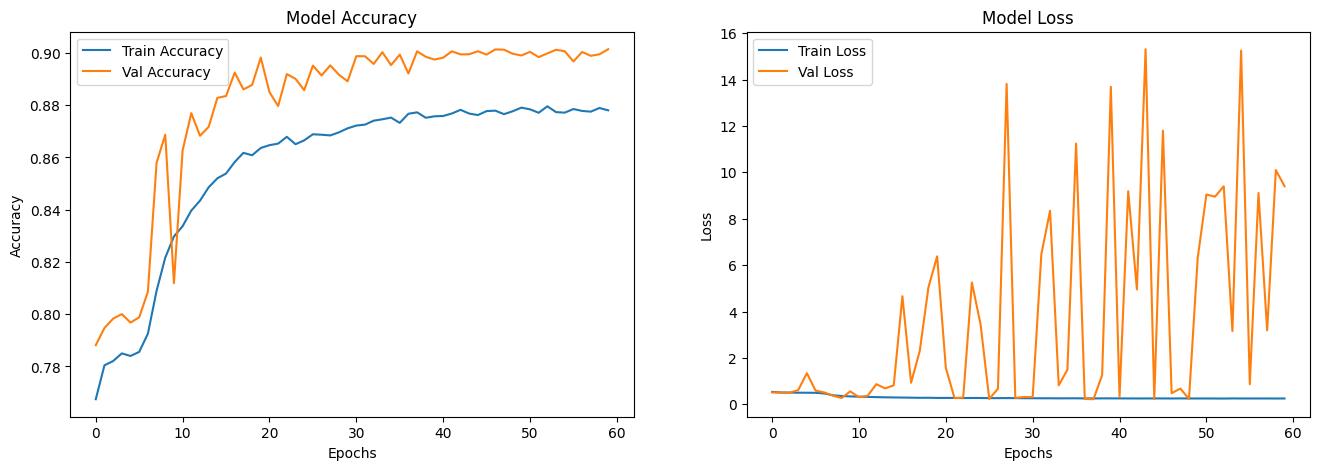

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# ---- 1. Plot Training History ----
plt.figure(figsize=(16,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()





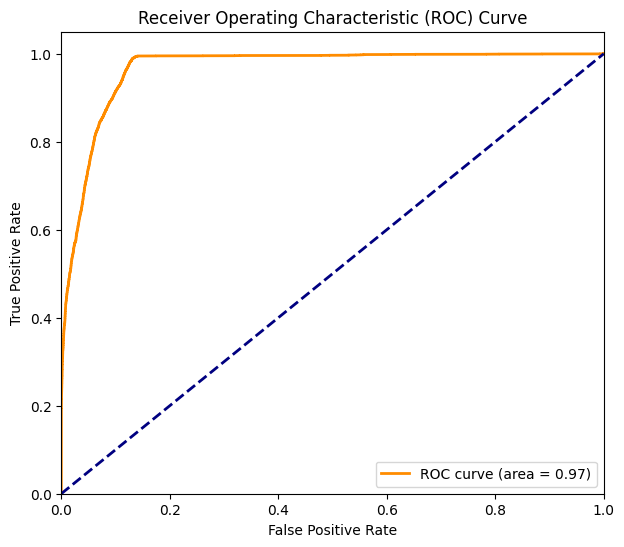

In [53]:

# ---- 4. ROC Curve ----
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()




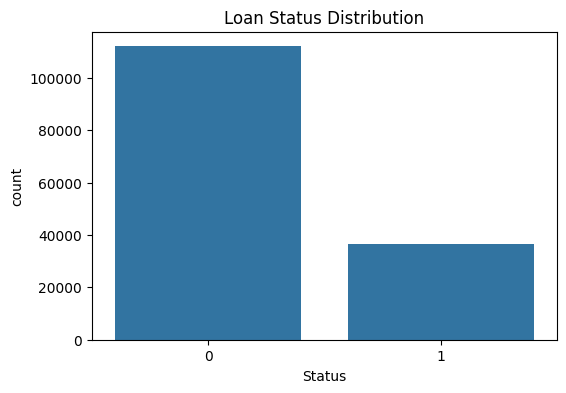

In [54]:
# ---- 5. Target Distribution ----
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Loan Status Distribution')
plt.show()